# 4. Analyze and Summarize 1910 Clusters

Inputs
- 1910_clusters.json
- 1910_embeddings.txt
- 1910_embeddings.npy
- 1910_photos/

Outputs
- 1910_cluster_stats.json (sizes, representative examples)
- 1910_cluster_concepts.json (top zero-shot concepts per cluster)
- 1910_cluster_top1_concept.json (top-1 zero-shot concept per cluster)


This notebook computes cluster statistics, selects representative images per cluster (centroid-nearest), and performs CLIP-style zero-shot concept labeling using the same model that produced our embeddings:
`SentenceTransformer("clip-ViT-B-32")` (512-D).

## Setup

In [ ]:
from pathlib import Path
import json
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from sentence_transformers import SentenceTransformer

/opt/anaconda3/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
# Paths
CLUSTERS_JSON = Path("1910_clusters.json")
EMB_TXT = Path("1910_embeddings.txt")
EMB_NPY = Path("1910_embeddings.npy")
PHOTOS_DIR = Path("1910_photos")
print("Using PHOTOS_DIR:", PHOTOS_DIR)

# Load clusters
clusters = json.loads(CLUSTERS_JSON.read_text(encoding="utf-8"))

# filenames and embeddings
filenames_1910 = [ln.strip() for ln in EMB_TXT.read_text(encoding="utf-8").splitlines() if ln.strip()]
embeddings_1910 = np.load(EMB_NPY)

print("Loaded clusters:", len(clusters))
print("filenames:", len(filenames_1910))
print("embeddings:", embeddings_1910.shape)

# Alignment check
if embeddings_1910.ndim != 2:
    raise ValueError(f"Expected 2D embedding matrix, got shape={embeddings_1910.shape}")

if len(filenames_1910) != embeddings_1910.shape[0]:
    raise ValueError(
        f"Row mismatch: {len(filenames_1910)} filenames vs {embeddings_1910.shape[0]} embedding rows"
    )

print("Alignment check passed.")

Using PHOTOS_DIR: 1910_photos
Loaded clusters: 2321
filenames: 72062
embeddings: (72062, 512)
Alignment check passed.


## Helpers

In [ ]:
# Usual helpers
def jpg_exists(rel_jpg: str) -> bool:
    return (PHOTOS_DIR / rel_jpg).exists()

def open_image(rel_jpg: str) -> Image.Image:
    p = PHOTOS_DIR / rel_jpg
    if not p.exists():
        raise FileNotFoundError(f"Missing image: {p}")
    return Image.open(p).convert("RGB")

def show_image_grid(rel_jpgs, title="", cols=6, figsize_per_cell=2.0, max_images=60):
    rel_jpgs = list(rel_jpgs)[:max_images]
    n = len(rel_jpgs)
    if n == 0:
        print("No images to display.")
        return

    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * figsize_per_cell, rows * figsize_per_cell))
    for j, rel in enumerate(rel_jpgs):
        ax = plt.subplot(rows, cols, j + 1)
        try:
            img = open_image(rel)
            ax.imshow(img)
            ax.set_title(f"{j}", fontsize=8)
        except Exception:
            ax.text(0.5, 0.5, "ERR", ha="center", va="center")
        ax.axis("off")

    if title:
        plt.suptitle(title)
    plt.show()

## Build lookup maps

In [19]:
# Build lookup maps (filename <-> index, and rel_jpg -> index)
idx_to_name = filenames_1910
name_to_idx = {name: i for i, name in enumerate(idx_to_name) if name not in idx_to_name[:i]}

def filename_to_reljpg(name: str) -> str:
    stem = str(Path(name))
    return f"{stem}.jpg"

reljpg_to_idx = {filename_to_reljpg(name): i for i, name in enumerate(filenames_1910)}

# rel_jpg -> cluster_id + duplicate check
jpg_to_cluster = {}
dupes = {}

for cid, jpg_list in clusters.items():
    for jpg in jpg_list:
        if jpg in jpg_to_cluster:
            dupes.setdefault(jpg, [jpg_to_cluster[jpg]]).append(cid)
        jpg_to_cluster[jpg] = cid

print("reljpg_to_idx entries:", len(reljpg_to_idx))
print("jpg_to_cluster entries:", len(jpg_to_cluster))

if dupes:
    print(f"{len(dupes)} images appear in more than one cluster. Showing first 10:")
    for jpg, cids in list(dupes.items())[:10]:
        print(" ", jpg, "->", cids)
else:
    print("No duplicate images across clusters.")


reljpg_to_idx entries: 72062
jpg_to_cluster entries: 6121
No duplicate images across clusters.


## Cluster statistics table + distribution plot

,cluster_id,size
0,84,106
1,88,62
2,4,62
3,39,57
4,125,41
5,89,32
6,90,32
7,94,32
8,134,28
9,561,21


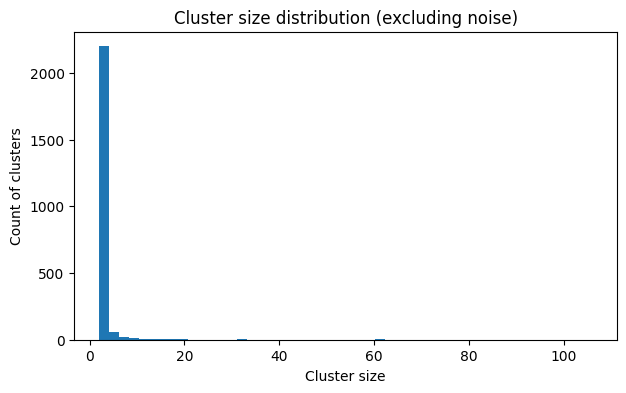

Total clusters: 2321
Total images in clusters: 6121


In [20]:
rows = []
for cid, rels in clusters.items():
    size = len(rels)
    rows.append({"cluster_id": cid, "size": size})

stats_df = pd.DataFrame(rows).sort_values("size", ascending=False).reset_index(drop=True)
display(stats_df.head(30))

plt.figure(figsize=(7,4))
plt.hist(stats_df["size"].values, bins=50)
plt.title("Cluster size distribution (excluding noise)")
plt.xlabel("Cluster size")
plt.ylabel("Count of clusters")
plt.show()

print("Total clusters:", len(stats_df))
print("Total images in clusters:", int(stats_df["size"].sum()))


## Representative images per cluster (centroid-nearest)

Picking images with embeddings closest to the cluster mean

Top cluster: 84 | reps: 5


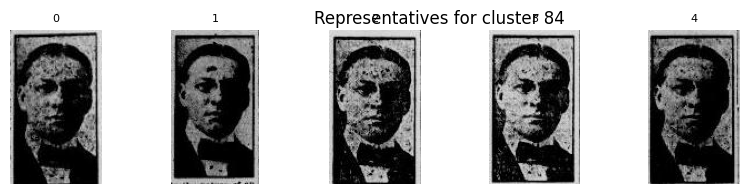

In [23]:
def representative_reljpgs(cid: str, k):
    rels_work = clusters[cid]
    if not rels_work:
        return []

    idxs = [reljpg_to_idx[r] for r in rels_work if r in reljpg_to_idx]
    if not idxs:
        return []

    X = embeddings_1910[idxs]   # (m = cluster size, D)
    center = X.mean(axis=0)  # (D,)
    d = np.linalg.norm(X - center, axis=1)
    top = np.argsort(d)[:min(k, len(idxs))]

    return [rels_work[int(t)] for t in top]

# Preview representatives for the largest cluster
top_cid = stats_df.loc[0, "cluster_id"]
reps = representative_reljpgs(top_cid, k=5)
print("Top cluster:", top_cid, "| reps:", len(reps))
show_image_grid(reps, title=f"Representatives for cluster {top_cid}", cols=6, max_images=24)

In [24]:
cluster_stats = {}

for _, row in stats_df.iterrows():
    cid = row["cluster_id"]
    cluster_stats[cid] = {
        "size": int(row["size"]),
        "representatives": representative_reljpgs(cid, k=2),
    }

out_stats = Path("1910_cluster_stats.json")
out_stats.write_text(json.dumps(cluster_stats, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out_stats)

Saved: 1910_cluster_stats.json


## Zero-shot concept labeling

In [ ]:
print("Loading model: sentence-transformers/clip-ViT-B-32")
clip_model = SentenceTransformer("clip-ViT-B-32")

print("Text embedding dim:", clip_model.get_sentence_embedding_dimension())
print("Image embedding dim:", embeddings_1910.shape[1])

Loading model: sentence-transformers/clip-ViT-B-32


modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Text embedding dim: None
Image embedding dim: 512


In [30]:
# Concept prompts
LABELS = [
    "portrait",
    "group of people",
    "building",
    "landscape",
    "document",
    "map or diagram",
    "advertisement",
    "vehicle",
    "animal",
    "military",
]

PROMPTS = [f"a photo of a {lab}" for lab in LABELS]
print("Number of labels:", len(LABELS))
print("Example prompts:", PROMPTS[:3])


Number of labels: 10
Example prompts: ['a photo of a portrait', 'a photo of a group of people', 'a photo of a building']


In [ ]:
# Embed prompts and normalize for cosine similarity
text_vecs = clip_model.encode( # SentenceTransformers API
    PROMPTS,
    convert_to_numpy=True,
    normalize_embeddings=True
)

print("text_vecs shape:", text_vecs.shape)  

text_vecs shape: (10, 512)


In [32]:
# Normalize image embeddings for cosine similarity
img_vecs = embeddings_1910 / np.linalg.norm(embeddings_1910, axis=1, keepdims=True)

def top_concepts_for_cluster(cid: str, topk=3):
    rels = clusters[cid]
    if not rels:
        return []

    idxs = [reljpg_to_idx[r] for r in rels if r in reljpg_to_idx]
    if not idxs:
        return []

    X = img_vecs[idxs]            
    sims = X @ text_vecs.T       
    mean_scores = sims.mean(axis=0)

    best = np.argsort(mean_scores)[::-1][:topk]
    return [{"label": LABELS[i], "score": float(mean_scores[i])} for i in best]

# Preview concepts for a few large clusters
for cid in stats_df["cluster_id"].head(5):
    print("Cluster", cid, "top concepts:", top_concepts_for_cluster(cid))

Cluster 84 top concepts: [{'label': 'portrait', 'score': 0.2464357167482376}, {'label': 'document', 'score': 0.22777728736400604}, {'label': 'advertisement', 'score': 0.214821457862854}]
Cluster 88 top concepts: [{'label': 'portrait', 'score': 0.2585679292678833}, {'label': 'document', 'score': 0.23285572230815887}, {'label': 'advertisement', 'score': 0.23020371794700623}]
Cluster 4 top concepts: [{'label': 'landscape', 'score': 0.2651765048503876}, {'label': 'document', 'score': 0.26378828287124634}, {'label': 'portrait', 'score': 0.2558417022228241}]
Cluster 39 top concepts: [{'label': 'portrait', 'score': 0.2565936744213104}, {'label': 'document', 'score': 0.23846104741096497}, {'label': 'advertisement', 'score': 0.22095544636249542}]
Cluster 125 top concepts: [{'label': 'portrait', 'score': 0.2559845745563507}, {'label': 'document', 'score': 0.23929879069328308}, {'label': 'advertisement', 'score': 0.22767779231071472}]


In [33]:
# Save 1910_cluster_concepts.json
cluster_concepts = {}
for cid in clusters.keys():
    cluster_concepts[cid] = {
        "top_concepts": top_concepts_for_cluster(cid, topk=3)
    }

out_concepts = Path("1910_cluster_concepts.json")
out_concepts.write_text(json.dumps(cluster_concepts, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", out_concepts)

Saved: 1910_cluster_concepts.json


Cluster: 84
Top concepts:
  portrait (0.246)
  document (0.228)
  advertisement (0.215)


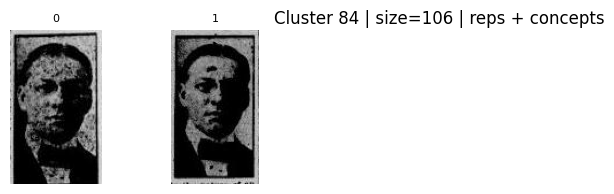

Cluster: 88
Top concepts:
  portrait (0.259)
  document (0.233)
  advertisement (0.230)


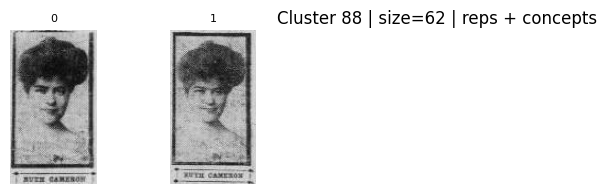

Cluster: 4
Top concepts:
  landscape (0.265)
  document (0.264)
  portrait (0.256)


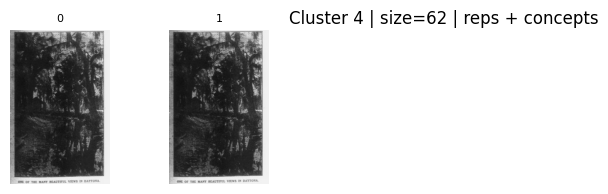

Cluster: 39
Top concepts:
  portrait (0.257)
  document (0.238)
  advertisement (0.221)


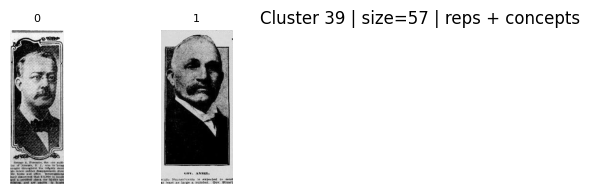

Cluster: 125
Top concepts:
  portrait (0.256)
  document (0.239)
  advertisement (0.228)


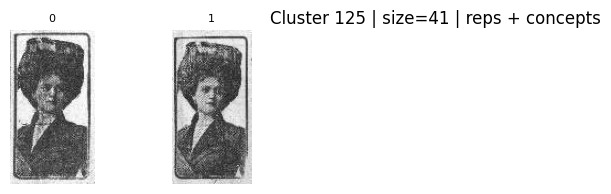

In [35]:
# Show representatives + concepts together for the 5 largest clusters

top5 = stats_df["cluster_id"].head(5).tolist()

for cid in top5:
    reps = cluster_stats[cid]["representatives"]
    concepts = cluster_concepts[cid]["top_concepts"]

    print("=" * 80)
    print("Cluster:", cid)
    print("Top concepts:")
    for c in concepts:
        print(" ", c["label"], f"({c['score']:.3f})")

    show_image_grid(
        reps,
        title=f"Cluster {cid} | size={cluster_stats[cid]['size']} | reps + concepts",
        cols=6,
        max_images=24
    )

In [37]:
def top1_concept(cid: str):
    rels = clusters[cid]
    if not rels:
        return None  

    idxs = [reljpg_to_idx[r] for r in rels if r in reljpg_to_idx]
    if not idxs:
        return None

    X = img_vecs[idxs]          
    sims = X @ text_vecs.T     
    mean_scores = sims.mean(axis=0)

    best_i = int(np.argmax(mean_scores))
    return {
        "label": LABELS[best_i],
        "score": float(mean_scores[best_i]),
    }

# Build top-1 dict for all clusters
cluster_top1 = {}
for cid in clusters.keys():
    top1 = top1_concept(cid)
    if top1 is not None:
        cluster_top1[cid] = top1

print("Clusters labeled (top-1):", len(cluster_top1), "out of", len(clusters))

Clusters labeled (top-1): 2321 out of 2321


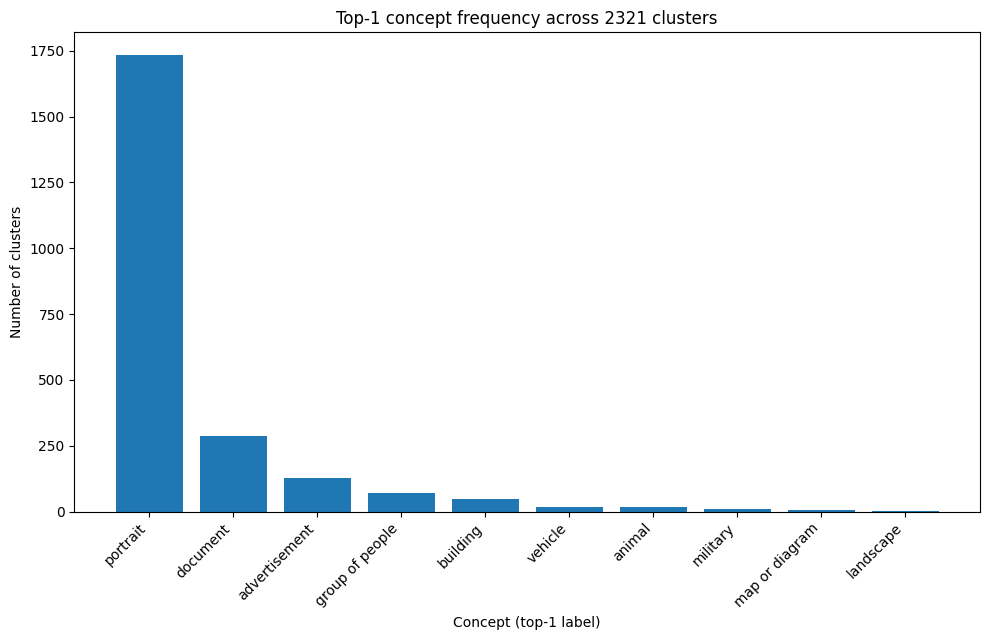

In [40]:
from collections import Counter

# Count concept assignments
counts = Counter(v["label"] for v in cluster_top1.values())

# Sort by count (descending)
labels_sorted = [k for k, _ in counts.most_common()]
values_sorted = [counts[k] for k in labels_sorted]

plt.figure(figsize=(10, 4 + 0.25 * len(labels_sorted)))
plt.bar(labels_sorted, values_sorted)
plt.title("Top-1 concept frequency across 2321 clusters")
plt.xlabel("Concept (top-1 label)")
plt.ylabel("Number of clusters")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [39]:
Path("1910_cluster_top1_concept.json").write_text(
    json.dumps(cluster_top1, ensure_ascii=False, indent=2),
    encoding="utf-8"
)
print("Saved: 1910_cluster_top1_concept.json")


Saved: 1910_cluster_top1_concept.json
